In [1]:
import os
import math
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from astropy.table import Table, Column

from spisea import synthetic, evolution, atmospheres, reddening

/home/wyz5rge/.venv/nbody/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /home/wyz5rge/SPISEA/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [2]:
# --------------------------------------------------
# Age grid
# --------------------------------------------------
AGE_MIN_MYR = 1.0
AGE_MAX_MYR = 20.0
AGE_STEP_MYR = 0.5

ISO_AGES_MYR = np.arange(
    AGE_MIN_MYR,
    AGE_MAX_MYR + 0.5 * AGE_STEP_MYR,
    AGE_STEP_MYR
)

LOG_AGES = np.log10(ISO_AGES_MYR * 1e6)

print(f"Number of requested ages: {len(ISO_AGES_MYR)}")
print("Ages (Myr):")
print(ISO_AGES_MYR)


# --------------------------------------------------
# SPISEA photometric settings
# --------------------------------------------------
AKs = 0.0
dist = 410
metallicity = 0.0

# Keep this consistent with the rest of the project.
atm_func = atmospheres.get_BTSettl_2015_atmosphere
red_law = reddening.RedLawHosek18b()

FILT_LIST = [
    'jwst,F182M',
    'jwst,F200W',
]

FILTER_KEYS = [
    'm_jwst_F182M',
    'm_jwst_F200W',
]


# --------------------------------------------------
# Merged evolution grid
# --------------------------------------------------
MERGED_MODEL_ROOT = Path(
    '/home/wyz5rge/SPISEA/evolution/merged/'
    'baraffe_pisa_ekstrom_parsec/'
)

# For your updated copy, replace the path above with something like:
#
# MERGED_MODEL_ROOT = Path(
#     '/path/to/merged_baraffe_0p01_updated/'
# )


# --------------------------------------------------
# Photometric isochrone cache
# --------------------------------------------------
ISO_CACHE_ROOT = Path('./')

ISO_CACHE_ROOT.mkdir(parents=True, exist_ok=True)

Number of requested ages: 39
Ages (Myr):
[ 1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.   7.5
  8.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5 13.  13.5 14.  14.5
 15.  15.5 16.  16.5 17.  17.5 18.  18.5 19.  19.5 20. ]


In [3]:
class MergedBaraffePisaEkstromParsecDAT:
    """
    Compatibility reader for the SPISEA merged evolution model stored
    as ASCII iso_*.dat files.

    The root directory must contain:
        z015_rot/
        z015_norot/
    """

    def __init__(self, root_dir, rot=True):
        self.root_dir = Path(root_dir).expanduser().resolve()
        self.rot = bool(rot)

        self.model_dir = str(self.root_dir)
        self.z_list = [0.015]
        self.z_solar = 0.015
        self.mass_list = []

        self.grid_dir = self.root_dir / (
            'z015_rot' if self.rot else 'z015_norot'
        )

        if not self.grid_dir.is_dir():
            raise FileNotFoundError(
                f"Merged-model directory not found: {self.grid_dir}"
            )

        paths = sorted(self.grid_dir.glob('iso_*.dat'))

        if len(paths) == 0:
            raise FileNotFoundError(
                f"No iso_*.dat files found in {self.grid_dir}"
            )

        self.age_file_map = {}

        for path in paths:
            try:
                log_age = float(path.stem.split('_')[1])
            except (IndexError, ValueError):
                continue

            self.age_file_map[round(log_age, 2)] = path

        self.age_list = np.array(
            sorted(self.age_file_map.keys()),
            dtype=float
        )

    def isochrone(self, age=1.0e6, metallicity=0.0):
        log_age_requested = math.log10(age)

        if log_age_requested < self.age_list[0]:
            raise ValueError(
                f"Requested logAge={log_age_requested:.4f} is younger "
                f"than the grid minimum logAge={self.age_list[0]:.2f}."
            )

        if log_age_requested > self.age_list[-1]:
            raise ValueError(
                f"Requested logAge={log_age_requested:.4f} is older "
                f"than the grid maximum logAge={self.age_list[-1]:.2f}."
            )

        # Select the nearest available grid age.
        age_idx = np.argmin(
            np.abs(self.age_list - log_age_requested)
        )
        selected_log_age = float(self.age_list[age_idx])

        iso_path = self.age_file_map[
            round(selected_log_age, 2)
        ]

        dtype = [
            ('mass', 'f8'),
            ('logT', 'f8'),
            ('logL', 'f8'),
            ('logg', 'f8'),
            ('logT_WR', 'f8'),
            ('mass_current', 'f8'),
            ('phase', 'i4'),
            ('model_ref', 'U32'),
        ]

        data = np.genfromtxt(
            str(iso_path),
            comments='#',
            dtype=dtype,
            encoding='utf-8'
        )

        # np.genfromtxt can return a scalar record if a file has one row.
        data = np.atleast_1d(data)
        iso = Table(data)

        is_wr = ~np.isclose(
            np.asarray(iso['logT'], dtype=float),
            np.asarray(iso['logT_WR'], dtype=float),
            rtol=0.0,
            atol=1e-8
        )

        iso.add_column(
            Column(is_wr, name='isWR')
        )

        iso.meta['log_age'] = selected_log_age
        iso.meta['log_age_requested'] = log_age_requested
        iso.meta['metallicity_in'] = metallicity
        iso.meta['metallicity_act'] = 0.0
        iso.meta['source_file'] = str(iso_path)

        return iso

In [4]:
MODEL_SPECS = {
    'Baraffe15': {
        'model': evolution.Baraffe15(),
        'cache_name': 'baraffe15',
    },

    'Pisa': {
        'model': evolution.Pisa(),
        'cache_name': 'pisa',
    },

    'Merged, rotating': {
        'model': MergedBaraffePisaEkstromParsecDAT(
            MERGED_MODEL_ROOT,
            rot=True
        ),
        'cache_name': 'merged_dat_rot',
    },

    'Merged, nonrotating': {
        'model': MergedBaraffePisaEkstromParsecDAT(
            MERGED_MODEL_ROOT,
            rot=False
        ),
        'cache_name': 'merged_dat_norot',
    },
}

In [5]:
for model_name, spec in MODEL_SPECS.items():
    model = spec['model']

    print(f"\n{model_name}")
    print("  class:", type(model))
    print("  model_dir:", getattr(model, 'model_dir', None))
    print("  grid_dir:", getattr(model, 'grid_dir', None))


Baraffe15
  class: <class 'spisea.evolution.Baraffe15'>
  model_dir: /home/wyz5rge/SPISEA/evolution/Baraffe15/
  grid_dir: None

Pisa
  class: <class 'spisea.evolution.Pisa'>
  model_dir: /home/wyz5rge/SPISEA/evolution/Pisa2011/
  grid_dir: None

Merged, rotating
  class: <class '__main__.MergedBaraffePisaEkstromParsecDAT'>
  model_dir: /sfs/gpfs/tardis/home/wyz5rge/SPISEA/evolution/merged/baraffe_pisa_ekstrom_parsec
  grid_dir: /sfs/gpfs/tardis/home/wyz5rge/SPISEA/evolution/merged/baraffe_pisa_ekstrom_parsec/z015_rot

Merged, nonrotating
  class: <class '__main__.MergedBaraffePisaEkstromParsecDAT'>
  model_dir: /sfs/gpfs/tardis/home/wyz5rge/SPISEA/evolution/merged/baraffe_pisa_ekstrom_parsec
  grid_dir: /sfs/gpfs/tardis/home/wyz5rge/SPISEA/evolution/merged/baraffe_pisa_ekstrom_parsec/z015_norot


In [6]:
for model_name, spec in MODEL_SPECS.items():
    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    try:
        iso = spec['model'].isochrone(
            age=1.0e6,
            metallicity=metallicity
        )

        print("Columns:", iso.colnames)
        print(
            "Mass range:",
            np.min(iso['mass']),
            np.max(iso['mass'])
        )
        print("Number of points:", len(iso))

        if 'source_file' in iso.meta:
            print("Source file:", iso.meta['source_file'])

    except Exception as exc:
        print("FAILED:", exc)


Baraffe15
Columns: ['mass', 'Teff', 'logL', 'logg', 'Rad', 'logT', 'logT_WR', 'isWR', 'phase', 'mass_current']
Mass range: 0.01 1.4
Number of points: 30

Pisa
Columns: ['logL', 'logT', 'mass', 'logg', 'logT_WR', 'isWR', 'phase', 'mass_current']
Mass range: 0.2 6.9993877
Number of points: 1026

Merged, rotating
Columns: ['mass', 'logT', 'logL', 'logg', 'logT_WR', 'mass_current', 'phase', 'model_ref', 'isWR']
Mass range: 0.01 500.0
Number of points: 1178
Source file: /sfs/gpfs/tardis/home/wyz5rge/SPISEA/evolution/merged/baraffe_pisa_ekstrom_parsec/z015_rot/iso_6.00.dat

Merged, nonrotating
Columns: ['mass', 'logT', 'logL', 'logg', 'logT_WR', 'mass_current', 'phase', 'model_ref', 'isWR']
Mass range: 0.01 500.0
Number of points: 1178
Source file: /sfs/gpfs/tardis/home/wyz5rge/SPISEA/evolution/merged/baraffe_pisa_ekstrom_parsec/z015_norot/iso_6.00.dat


In [7]:
def build_physical_isochrone_grid(
    evo_model,
    ages_myr=ISO_AGES_MYR
):
    rows = []
    iso_grid = []

    for requested_age_myr in ages_myr:
        requested_log_age = np.log10(
            requested_age_myr * 1e6
        )

        try:
            iso = evo_model.isochrone(
                age=requested_age_myr * 1e6,
                metallicity=metallicity
            )

            mass = np.asarray(iso['mass'], dtype=float)
            log_t = np.asarray(iso['logT'], dtype=float)
            log_l = np.asarray(iso['logL'], dtype=float)

            good = (
                np.isfinite(mass) &
                np.isfinite(log_t) &
                np.isfinite(log_l)
            )

            mass = mass[good]
            log_t = log_t[good]
            log_l = log_l[good]

            iso_grid.append({
                'requested_age_myr': requested_age_myr,
                'requested_log_age': requested_log_age,
                'actual_log_age': iso.meta.get(
                    'log_age',
                    requested_log_age
                ),
                'mass': mass,
                'logT': log_t,
                'Teff': 10**log_t,
                'logL': log_l,
            })

            rows.append({
                'requested_age_myr': requested_age_myr,
                'requested_log_age': requested_log_age,
                'actual_log_age': iso.meta.get(
                    'log_age',
                    requested_log_age
                ),
                'mass_min': np.min(mass),
                'mass_max': np.max(mass),
                'n_points': len(mass),
                'status': 'success',
                'error': '',
            })

        except Exception as exc:
            print(
                f"Failed at age={requested_age_myr:.2f} Myr: "
                f"{exc}"
            )

            rows.append({
                'requested_age_myr': requested_age_myr,
                'requested_log_age': requested_log_age,
                'actual_log_age': np.nan,
                'mass_min': np.nan,
                'mass_max': np.nan,
                'n_points': 0,
                'status': 'failed',
                'error': str(exc),
            })

    return iso_grid, pd.DataFrame(rows)

In [8]:
PHYSICAL_GRIDS = {}
PHYSICAL_COVERAGE = {}

for model_name, spec in MODEL_SPECS.items():
    print(f"\nBuilding physical grid: {model_name}")

    grid, coverage = build_physical_isochrone_grid(
        spec['model']
    )

    PHYSICAL_GRIDS[model_name] = grid
    PHYSICAL_COVERAGE[model_name] = coverage


Building physical grid: Baraffe15

Building physical grid: Pisa

Building physical grid: Merged, rotating

Building physical grid: Merged, nonrotating


In [9]:
coverage_rows = []

for model_name, coverage in PHYSICAL_COVERAGE.items():
    successful = coverage[
        coverage['status'] == 'success'
    ]

    if len(successful) == 0:
        coverage_rows.append({
            'model': model_name,
            'youngest_successful_age_myr': np.nan,
            'oldest_successful_age_myr': np.nan,
            'minimum_mass_across_grid': np.nan,
            'maximum_mass_across_grid': np.nan,
            'successful_ages': 0,
        })
        continue

    coverage_rows.append({
        'model': model_name,
        'youngest_successful_age_myr':
            successful['requested_age_myr'].min(),
        'oldest_successful_age_myr':
            successful['requested_age_myr'].max(),
        'minimum_mass_across_grid':
            successful['mass_min'].min(),
        'maximum_mass_across_grid':
            successful['mass_max'].max(),
        'successful_ages': len(successful),
    })

df_physical_summary = pd.DataFrame(coverage_rows)
df_physical_summary

,model,youngest_successful_age_myr,oldest_successful_age_myr,minimum_mass_across_grid,maximum_mass_across_grid,successful_ages
0,Baraffe15,1.0,20.0,0.01,1.400000,39
1,Pisa,1.0,20.0,0.20,6.999388,39
2,"Merged, rotating",1.0,20.0,0.01,500.000000,39
3,"Merged, nonrotating",1.0,20.0,0.01,500.000000,39


In [10]:
def plot_hr_model_comparison(
    physical_grids,
    ages_myr=ISO_AGES_MYR
):
    n_models = len(physical_grids)
    ncols = 2
    nrows = math.ceil(n_models / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(13, 5.5 * nrows),
        squeeze=False
    )
    axes = axes.flatten()

    cmap = plt.get_cmap('coolwarm')
    norm = Normalize(
        vmin=np.min(ages_myr),
        vmax=np.max(ages_myr)
    )

    for ax, (model_name, grid) in zip(
        axes,
        physical_grids.items()
    ):
        grid_min_masses = []
        grid_max_masses = []

        for iso in grid:
            age_myr = iso['requested_age_myr']

            ax.plot(
                iso['Teff'],
                iso['logL'],
                color=cmap(norm(age_myr)),
                alpha=0.65,
                lw=1.0
            )

            grid_min_masses.append(
                np.min(iso['mass'])
            )
            grid_max_masses.append(
                np.max(iso['mass'])
            )

        if len(grid_min_masses) > 0:
            annotation = (
                "Mass coverage\n"
                f"{min(grid_min_masses):.3f}–"
                f"{max(grid_max_masses):.1f} "
                r"$M_\odot$"
            )
        else:
            annotation = "No valid isochrones"

        ax.text(
            0.03,
            0.97,
            annotation,
            transform=ax.transAxes,
            ha='left',
            va='top',
            bbox=dict(
                boxstyle='round',
                facecolor='white',
                alpha=0.85
            )
        )

        ax.set_title(model_name)
        ax.set_xlabel(r'$T_{\rm eff}$ (K)')
        ax.set_ylabel(r'$\log_{10}(L/L_\odot)$')
        ax.invert_xaxis()
        ax.grid(alpha=0.2)

    for ax in axes[n_models:]:
        ax.axis('off')

    sm = ScalarMappable(
        norm=norm,
        cmap=cmap
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes[:n_models].tolist(),
        pad=0.02
    )
    cbar.set_label('Isochrone age (Myr)')

    fig.suptitle(
        'H–R isochrone geometry by evolution model',
        fontsize=15
    )

    # plt.tight_layout()
    plt.show()

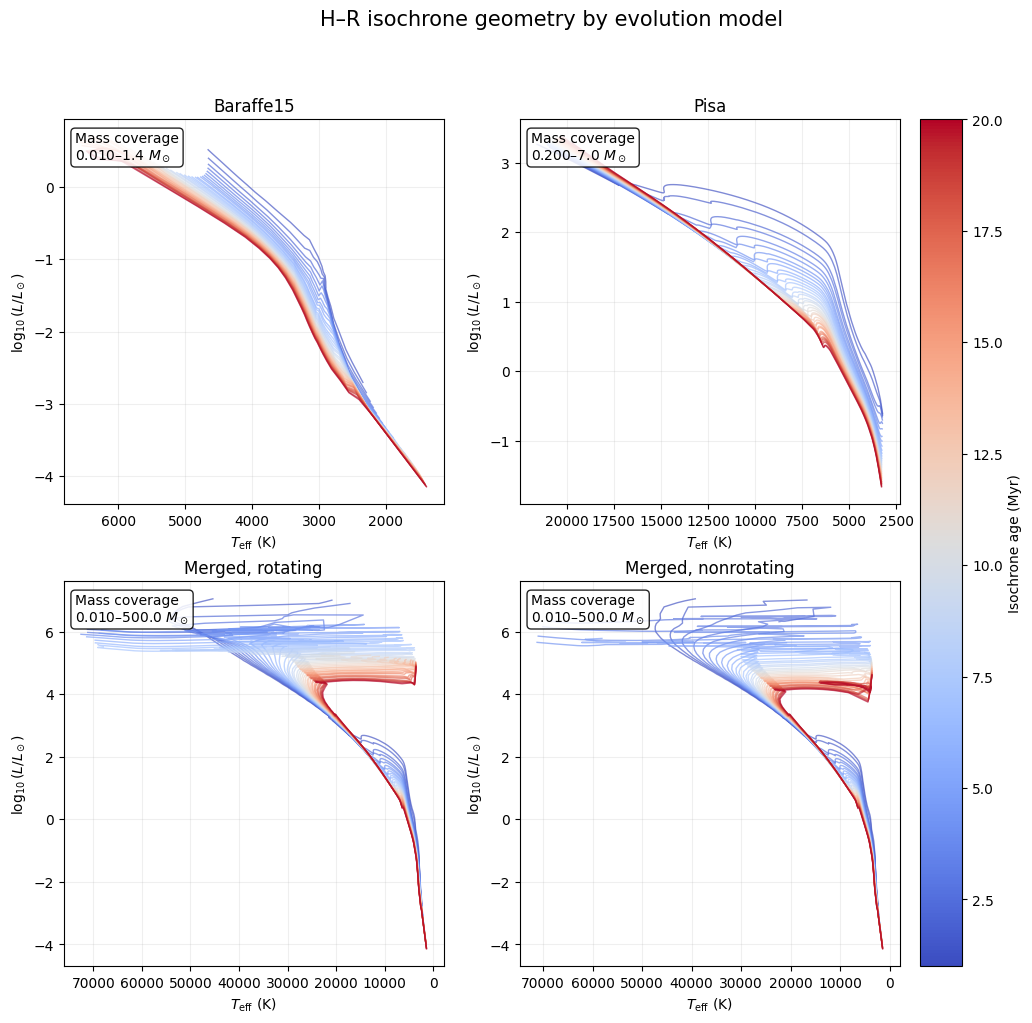

In [11]:
plot_hr_model_comparison(PHYSICAL_GRIDS)

In [12]:
def plot_hr_low_mass_zoom(
    physical_grids,
    teff_min=2200,
    teff_max=6000,
    logl_min=-4.0,
    logl_max=2.0
):
    n_models = len(physical_grids)
    ncols = 2
    nrows = math.ceil(n_models / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(13, 5.5 * nrows),
        squeeze=False
    )
    axes = axes.flatten()

    cmap = plt.get_cmap('coolwarm')
    norm = Normalize(
        vmin=ISO_AGES_MYR.min(),
        vmax=ISO_AGES_MYR.max()
    )

    for ax, (model_name, grid) in zip(
        axes,
        physical_grids.items()
    ):
        for iso in grid:
            ax.plot(
                iso['Teff'],
                iso['logL'],
                color=cmap(
                    norm(iso['requested_age_myr'])
                ),
                alpha=0.65,
                lw=1.0
            )

        ax.axvspan(
            3000,
            3600,
            alpha=0.08,
            label='Masegian temperature interval'
        )

        ax.set_xlim(teff_max, teff_min)
        ax.set_ylim(logl_min, logl_max)

        ax.set_title(model_name)
        ax.set_xlabel(r'$T_{\rm eff}$ (K)')
        ax.set_ylabel(r'$\log_{10}(L/L_\odot)$')
        ax.grid(alpha=0.2)

    for ax in axes[n_models:]:
        ax.axis('off')

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes[:n_models].tolist(),
        pad=0.02
    )
    cbar.set_label('Isochrone age (Myr)')

    fig.suptitle(
        'Low-mass H–R isochrone geometry',
        fontsize=15
    )

    # plt.tight_layout()
    plt.show()

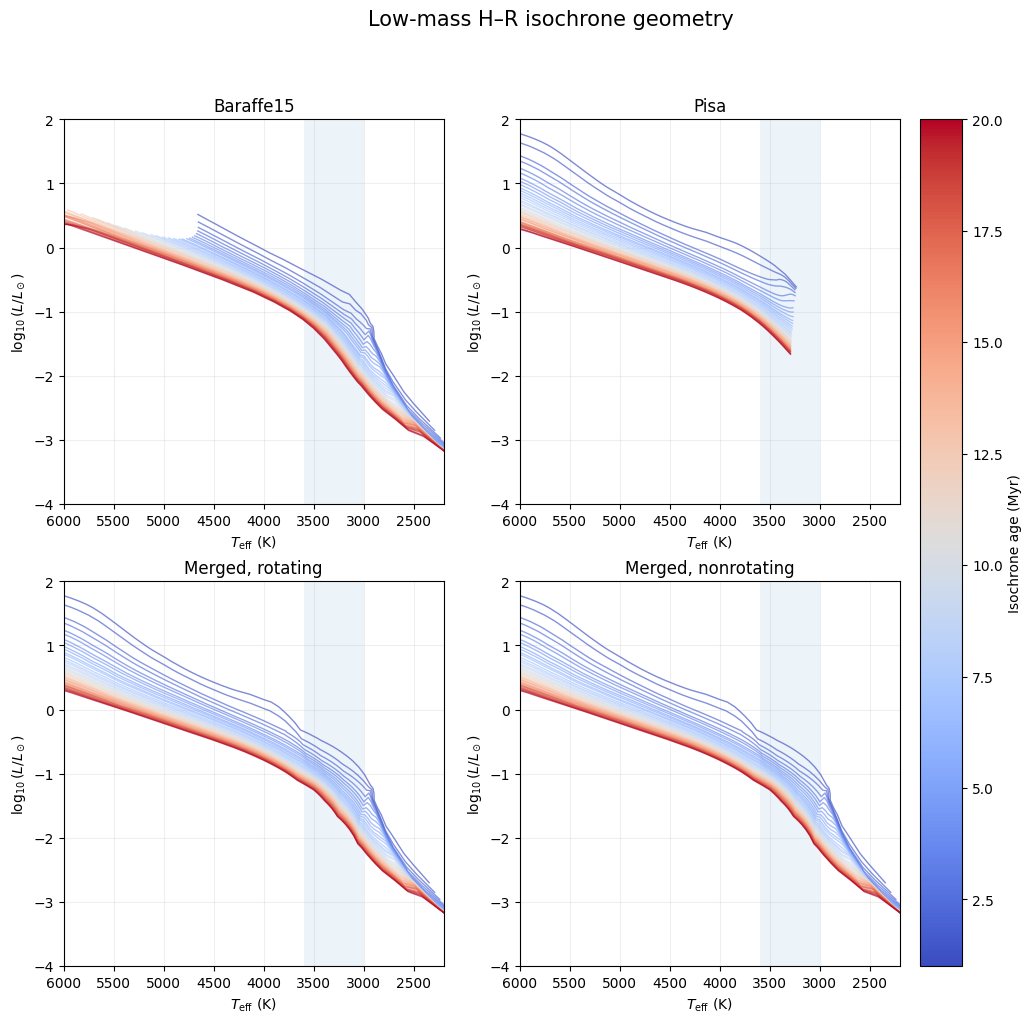

In [13]:
plot_hr_low_mass_zoom(PHYSICAL_GRIDS)

In [14]:
def build_photometric_isochrone_grid(
    evo_model,
    cache_name,
    log_ages=LOG_AGES
):
    model_iso_dir = ISO_CACHE_ROOT / cache_name
    model_iso_dir.mkdir(parents=True, exist_ok=True)

    iso_grid = []
    rows = []

    for requested_age_myr, log_age in zip(
        ISO_AGES_MYR,
        log_ages
    ):
        try:
            iso = synthetic.IsochronePhot(
                log_age,
                AKs,
                dist,
                metallicity=metallicity,
                evo_model=evo_model,
                atm_func=atm_func,
                red_law=red_law,
                filters=FILT_LIST,
                iso_dir=str(model_iso_dir)
            )

            required_columns = [
                'mass',
                FILTER_KEYS[0],
                FILTER_KEYS[1],
            ]

            missing = [
                col for col in required_columns
                if col not in iso.points.colnames
            ]

            if missing:
                raise KeyError(
                    f"Photometric isochrone is missing columns: "
                    f"{missing}"
                )

            mass = np.asarray(
                iso.points['mass'],
                dtype=float
            )
            mag182 = np.asarray(
                iso.points[FILTER_KEYS[0]],
                dtype=float
            )
            mag200 = np.asarray(
                iso.points[FILTER_KEYS[1]],
                dtype=float
            )

            color = mag182 - mag200

            good = (
                np.isfinite(mass) &
                np.isfinite(color) &
                np.isfinite(mag200)
            )

            mass = mass[good]
            color = color[good]
            mag200 = mag200[good]

            iso_grid.append({
                'requested_age_myr': requested_age_myr,
                'requested_log_age': log_age,
                'iso': iso,
                'mass': mass,
                'color': color,
                'mag200': mag200,
            })

            rows.append({
                'requested_age_myr': requested_age_myr,
                'requested_log_age': log_age,
                'mass_min': np.min(mass),
                'mass_max': np.max(mass),
                'n_points': len(mass),
                'status': 'success',
                'error': '',
            })

            print(
                f"age={requested_age_myr:4.1f} Myr complete "
                f"({len(mass)} valid points)"
            )

        except Exception as exc:
            print(
                f"FAILED: age={requested_age_myr:.1f} Myr: "
                f"{exc}"
            )

            rows.append({
                'requested_age_myr': requested_age_myr,
                'requested_log_age': log_age,
                'mass_min': np.nan,
                'mass_max': np.nan,
                'n_points': 0,
                'status': 'failed',
                'error': str(exc),
            })

    return iso_grid, pd.DataFrame(rows)

In [15]:
PHOTOMETRIC_GRIDS = {}
PHOTOMETRIC_COVERAGE = {}

for model_name, spec in MODEL_SPECS.items():
    print("\n" + "=" * 70)
    print(f"Building photometric grid: {model_name}")
    print("=" * 70)

    grid, coverage = build_photometric_isochrone_grid(
        spec['model'],
        spec['cache_name']
    )

    PHOTOMETRIC_GRIDS[model_name] = grid
    PHOTOMETRIC_COVERAGE[model_name] = coverage


Building photometric grid: Baraffe15
age= 1.0 Myr complete (30 valid points)
age= 1.5 Myr complete (30 valid points)
age= 2.0 Myr complete (30 valid points)
age= 2.5 Myr complete (30 valid points)
age= 3.0 Myr complete (30 valid points)
age= 3.5 Myr complete (30 valid points)
age= 4.0 Myr complete (30 valid points)
age= 4.5 Myr complete (30 valid points)
age= 5.0 Myr complete (30 valid points)
age= 5.5 Myr complete (30 valid points)
age= 6.0 Myr complete (30 valid points)
age= 6.5 Myr complete (30 valid points)
age= 7.0 Myr complete (30 valid points)
age= 7.5 Myr complete (30 valid points)
age= 8.0 Myr complete (30 valid points)
age= 8.5 Myr complete (30 valid points)
age= 9.0 Myr complete (30 valid points)
age= 9.5 Myr complete (30 valid points)
age=10.0 Myr complete (30 valid points)
age=10.5 Myr complete (30 valid points)
age=11.0 Myr complete (30 valid points)
age=11.5 Myr complete (30 valid points)
age=12.0 Myr complete (30 valid points)
age=12.5 Myr complete (30 valid points)
ag

In [16]:
photometric_summary_rows = []

for model_name, coverage in PHOTOMETRIC_COVERAGE.items():
    successful = coverage[
        coverage['status'] == 'success'
    ]

    if len(successful) == 0:
        photometric_summary_rows.append({
            'model': model_name,
            'minimum_photometric_mass': np.nan,
            'maximum_photometric_mass': np.nan,
            'successful_ages': 0,
            'failed_ages': len(coverage),
        })
        continue

    photometric_summary_rows.append({
        'model': model_name,
        'minimum_photometric_mass':
            successful['mass_min'].min(),
        'maximum_photometric_mass':
            successful['mass_max'].max(),
        'successful_ages': len(successful),
        'failed_ages':
            np.sum(coverage['status'] == 'failed'),
    })

df_photometric_summary = pd.DataFrame(
    photometric_summary_rows
)

df_photometric_summary

,model,minimum_photometric_mass,maximum_photometric_mass,successful_ages,failed_ages
0,Baraffe15,0.01,1.400000,39,0
1,Pisa,0.20,6.999388,39,0
2,"Merged, rotating",0.01,500.000000,39,0
3,"Merged, nonrotating",0.01,500.000000,39,0


In [17]:
def plot_cmd_model_comparison(
    photometric_grids,
    ages_myr=ISO_AGES_MYR
):
    n_models = len(photometric_grids)
    ncols = 2
    nrows = math.ceil(n_models / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(13, 5.5 * nrows),
        squeeze=False
    )
    axes = axes.flatten()

    cmap = plt.get_cmap('coolwarm')
    norm = Normalize(
        vmin=np.min(ages_myr),
        vmax=np.max(ages_myr)
    )

    for ax, (model_name, grid) in zip(
        axes,
        photometric_grids.items()
    ):
        min_masses = []
        max_masses = []

        for iso in grid:
            age_myr = iso['requested_age_myr']

            ax.plot(
                iso['color'],
                iso['mag200'],
                color=cmap(norm(age_myr)),
                alpha=0.65,
                lw=1.0
            )

            min_masses.append(
                np.min(iso['mass'])
            )
            max_masses.append(
                np.max(iso['mass'])
            )

        if len(min_masses) > 0:
            annotation = (
                "Photometric mass coverage\n"
                f"{min(min_masses):.3f}–"
                f"{max(max_masses):.1f} "
                r"$M_\odot$"
            )
        else:
            annotation = "No valid photometric isochrones"

        ax.text(
            0.03,
            0.97,
            annotation,
            transform=ax.transAxes,
            ha='left',
            va='top',
            bbox=dict(
                boxstyle='round',
                facecolor='white',
                alpha=0.85
            )
        )

        ax.set_title(model_name)
        ax.set_xlabel('F182M − F200W')
        ax.set_ylabel('F200W')
        ax.invert_yaxis()
        ax.grid(alpha=0.2)

    for ax in axes[n_models:]:
        ax.axis('off')

    sm = ScalarMappable(
        norm=norm,
        cmap=cmap
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes[:n_models].tolist(),
        pad=0.02
    )
    cbar.set_label('Isochrone age (Myr)')

    fig.suptitle(
        'F182M–F200W versus F200W isochrone geometry',
        fontsize=15
    )

    # plt.tight_layout()
    plt.show()

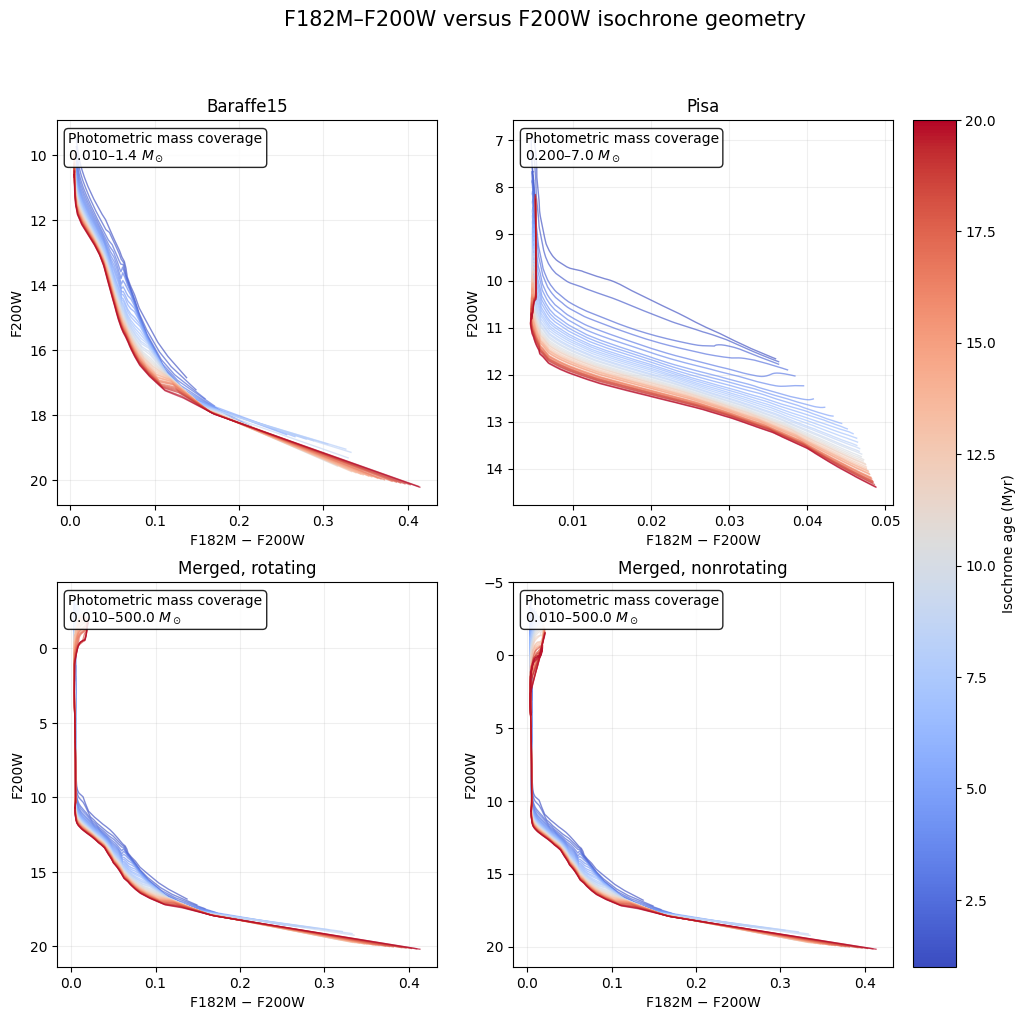

In [18]:
plot_cmd_model_comparison(PHOTOMETRIC_GRIDS)

In [19]:
def plot_combined_hr_cmd_comparison(
    physical_grids,
    photometric_grids
):
    model_names = [
        name for name in physical_grids
        if name in photometric_grids
    ]

    n_models = len(model_names)

    fig, axes = plt.subplots(
        n_models,
        2,
        figsize=(13, 4.8 * n_models),
        squeeze=False
    )

    cmap = plt.get_cmap('coolwarm')
    norm = Normalize(
        vmin=ISO_AGES_MYR.min(),
        vmax=ISO_AGES_MYR.max()
    )

    for row_idx, model_name in enumerate(model_names):
        physical_grid = physical_grids[model_name]
        photometric_grid = photometric_grids[model_name]

        # ------------------------------------------
        # H-R panel
        # ------------------------------------------
        ax_hr = axes[row_idx, 0]

        for iso in physical_grid:
            ax_hr.plot(
                iso['Teff'],
                iso['logL'],
                color=cmap(
                    norm(iso['requested_age_myr'])
                ),
                alpha=0.62,
                lw=0.9
            )

        ax_hr.set_title(f'{model_name}: H–R diagram')
        ax_hr.set_xlabel(r'$T_{\rm eff}$ (K)')
        ax_hr.set_ylabel(r'$\log_{10}(L/L_\odot)$')
        ax_hr.invert_xaxis()
        ax_hr.grid(alpha=0.2)

        # ------------------------------------------
        # CMD panel
        # ------------------------------------------
        ax_cmd = axes[row_idx, 1]

        for iso in photometric_grid:
            ax_cmd.plot(
                iso['color'],
                iso['mag200'],
                color=cmap(
                    norm(iso['requested_age_myr'])
                ),
                alpha=0.62,
                lw=0.9
            )

        ax_cmd.set_title(
            f'{model_name}: F182M–F200W vs F200W'
        )
        ax_cmd.set_xlabel('F182M − F200W')
        ax_cmd.set_ylabel('F200W')
        ax_cmd.invert_yaxis()
        ax_cmd.grid(alpha=0.2)

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes.ravel().tolist(),
        pad=0.015
    )
    cbar.set_label('Isochrone age (Myr)')

    fig.suptitle(
        'Theoretical isochrone geometry by evolution model',
        fontsize=16,
        y=1.002
    )

    # plt.tight_layout()
    plt.show()

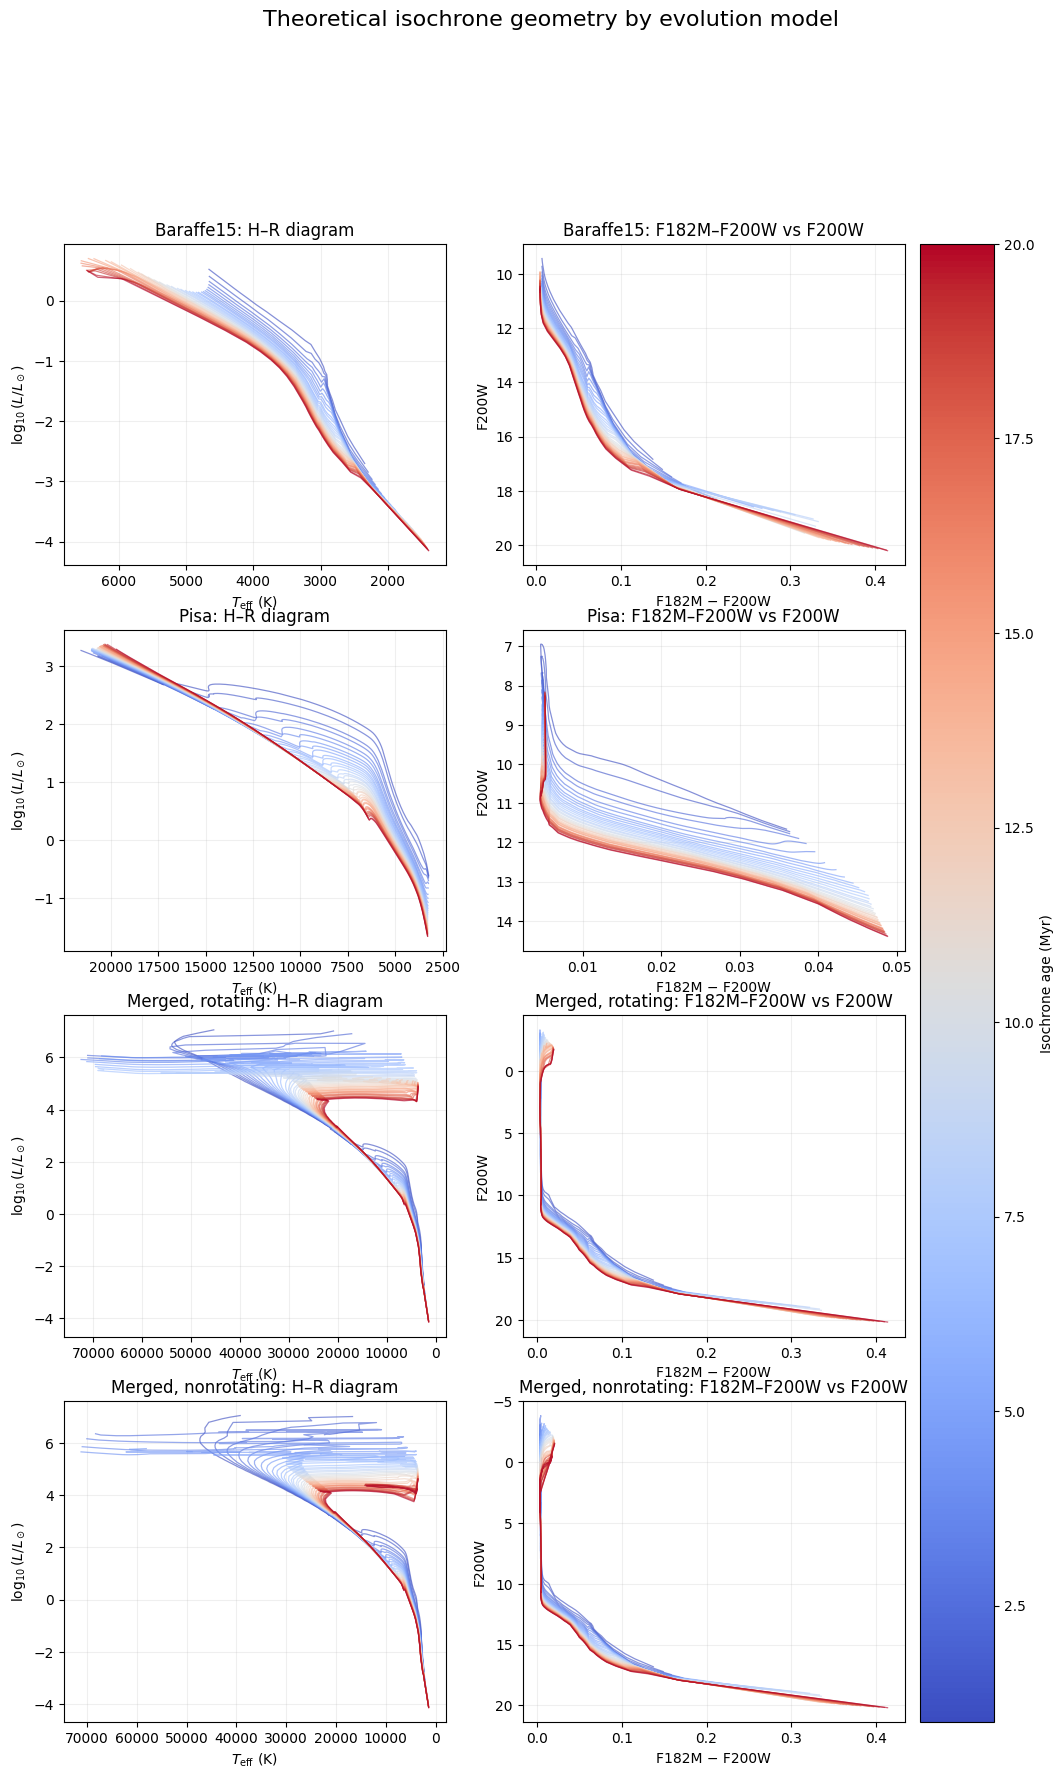

In [20]:
plot_combined_hr_cmd_comparison(
    PHYSICAL_GRIDS,
    PHOTOMETRIC_GRIDS
)